In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d
import abel
 
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
})

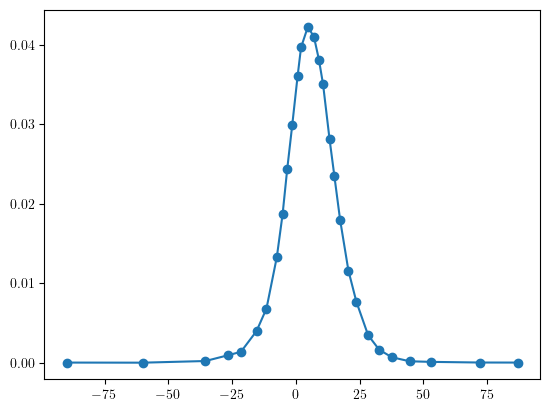

In [2]:
# read data from csv file as numpy array
data = np.loadtxt('q5_bulk_theta_orientation_borzsonyi.csv', delimiter=',', skiprows=1)
angles = data[:, 0]  # first column is angles
hist = data[:, 1]  # second column is histogram values
plt.plot(angles, hist, '-o', label='orientation distribution raw')

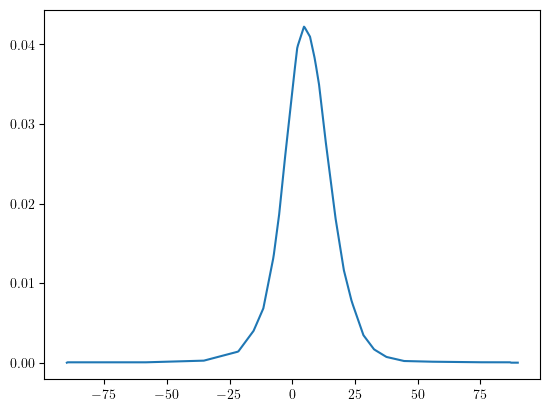

In [3]:
# 4. Interpolate to a uniform grid
num_points = 600
theta_uniform = np.linspace(-90, 90, num_points)
interp_func = interp1d(angles, hist, kind='linear', bounds_error=False, fill_value=0)
hist_uniform = interp_func(theta_uniform)
plt.plot(theta_uniform, hist_uniform, label='orientation distribution interpolated')

In [4]:
# find the circular mean of the angles distribution

theta_d = np.atan2(np.sum(np.sin(np.radians(theta_uniform)) * hist_uniform),
                     np.sum(np.cos(np.radians(theta_uniform)) * hist_uniform))

theta_d = np.degrees(theta_d)  # convert to degrees
print(f'Circular mean of the angles distribution: {theta_d:.2f} degrees')

Circular mean of the angles distribution: 5.77 degrees


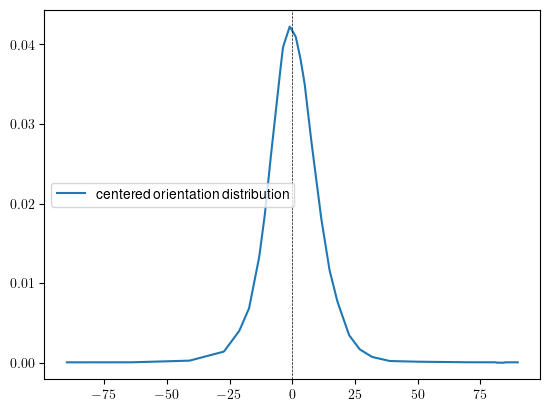

In [5]:
# find closest theta value to the circular mean
closest_index = np.argmin(np.abs(theta_uniform - theta_d))
closest_theta = theta_uniform[closest_index]
middle_index = num_points // 2

hist_centered = np.roll(hist_uniform, -closest_index + middle_index)
plt.plot(theta_uniform, hist_centered, label='centered orientation distribution')
plt.axvline(0, color='black', linestyle='--', linewidth=0.5)
plt.legend()

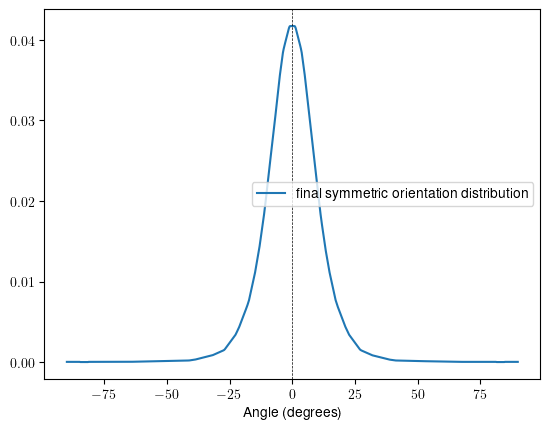

In [6]:
#make histogram symmetric

hist_sym = 0.5 * (hist_centered + np.flip(hist_centered))
plt.plot(theta_uniform, hist_sym, label='final symmetric orientation distribution')
plt.xlabel('Angle (degrees)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
plt.legend()


In [7]:
import numpy as np
from scipy.integrate import quad
from scipy.optimize import root_scalar
from scipy.optimize import brentq

def find_U_from_S2(target_S2, u_min=0.01, u_max=150.0, tol=1e-7):
    """
    Finds the interaction strength U that self-consistently produces a
    target nematic order parameter S2.
    
    Uses a root-finding algorithm on the function g(U) = solve_self_consistent_S2(U) - target_S2.
    
    Args:
        target_S2 (float): The desired nematic order parameter (e.g., from simulation).
        u_min (float): The lower bound of the search interval for U.
        u_max (float): The upper bound of the search interval for U.
        tol (float): The tolerance for the root-finding.

    Returns:
        float: The self-consistent interaction strength U.
    """
    # Handle the trivial isotropic case where U is effectively zero.
    if target_S2 <= 0.01:
        return 0.0
        
    # Define the objective function whose root we want to find.
    # The root occurs when the S2 produced by a given U equals our target S2.
    def objective_func(U):
        return solve_self_consistent_S2(U) - target_S2
    
    try:
        # Use Brent's method, a robust and fast bracketing root-finder.
        U_solution = brentq(objective_func, u_min, u_max, xtol=tol)
        return U_solution
    except ValueError:
        # This error occurs if the objective function does not have opposite signs
        # at the ends of the interval, meaning there is no root to be found.
        # This can happen if the target_S2 is too high to be physically reachable.
        print(f"Warning: Could not find a self-consistent U for target S2 = {target_S2:.3f}. "
              "The target may be outside the reachable range.")
        return np.nan


def calculate_S2_from_distribution(thetas, U, S2_guess):
    """
    For a given interaction strength U and a guessed order parameter S2_guess,
    this function calculates the resulting order parameter by averaging P₂(cosθ)
    over the corresponding Maier-Saupe distribution.
    """
    cos_thetas = np.cos(thetas)
    
    # Calculate the un-normalized probability
    numerator = np.exp(U * S2_guess * P2(cos_thetas))
    
    # Integrand for the partition function Z (normalization constant)
    integrand_Z = numerator * np.sin(thetas)
    Z_integral = np.trapezoid(integrand_Z, x=thetas)
    
    # Integrand for the average of P2
    integrand_P2 = P2(cos_thetas) * numerator * np.sin(thetas)
    P2_integral = np.trapezoid(integrand_P2, x=thetas)
    
    # Avoid division by zero if the integral is null
    if Z_integral == 0:
        return 0.0
        
    # The new S2 is the correctly weighted average of P2 over the distribution
    S2_new = P2_integral / Z_integral
    return S2_new

def solve_self_consistent_S2(U, initial_guess=0.8, tol=1e-7, max_iter=500):
    """
    Iteratively solves for the self-consistent nematic order parameter S2
    for a given interaction strength U.
    """
    S2 = initial_guess
    # Use a high-resolution grid for accurate numerical integration
    thetas = np.linspace(0, np.pi / 2, 500)
    
    for _ in range(max_iter):
        S2_new = calculate_S2_from_distribution(thetas, U, S2)
        if np.abs(S2 - S2_new) < tol:
            return S2_new  # Converged
        S2 = S2_new
        
    # If max_iter is reached without convergence, it may be the isotropic state
    if S2 < 0.05: # A reasonable threshold for the isotropic phase
        return 0.0
        
    # print(f"Warning: Self-consistency for U={U:.2f} did not converge. Returning last value: {S2:.3f}")
    return S2

def fit_equilibrium_ODF(measured_thetas, S, U):
    """
    Maier-Saupe equilibrium distribution per unit solid angle,
    using the second Legendre Polynomial P₂(cosθ).
    Accounts for head-tail symmetry (θ ∈ [0, π/2]).
    Normalization is computed over [0, π/2] and multiplied by 2 to account for symmetry.
    """
    cos_thetas = np.cos(measured_thetas)
    
    legendre_term = P2(cos_thetas)
    
    numerator = np.exp(S * U * legendre_term)
    
    integrand = numerator * np.sin(measured_thetas)
    denominator = 4 * np.pi * np.trapezoid(integrand, x=measured_thetas)
    
    return numerator / denominator

def P2(x):
    """Calculates the second Legendre polynomial, P₂(x) = (3x² - 1)/2."""
    return 0.5 * (3 * x**2 - 1.0)

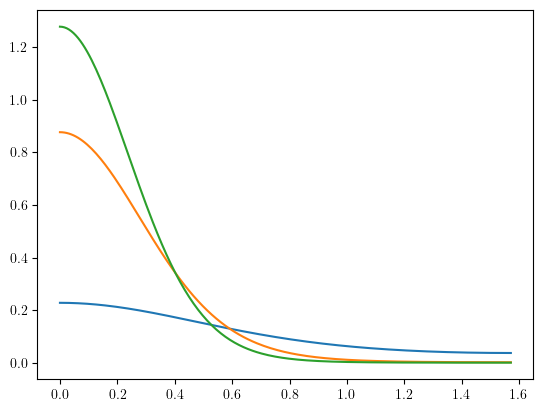

In [8]:
S_given = np.array([0.27, 0.72, 0.81])
density = np.array([0.495, 0.5, 0.48])
alphas = np.array([2.0, 3.3, 5.0])

Us = [find_U_from_S2(S) for S in S_given]

theta_vals = np.linspace(0, np.pi/2, 200)


for i, alpha in enumerate(alphas):
    # Plot the distribution
    f_vals = fit_equilibrium_ODF(theta_vals, S_given[i], Us[i])
   
    plt.plot(theta_vals , f_vals, label=f"U_fit = {Us[i]:.2f}, S = {S_given[i]:.2f}, α = {alpha:.1f}")
# plt.xlabel("θ (degrees)")
# plt.ylabel("f(θ)")
# plt.title(f"Maier–Saupe distribution for S = {S_given}")
# plt.legend()
plt.show()


Predicted U for alpha 2.0: 0.9281
Fitted U for alpha 2.0: 4.4864
Predicted U for alpha 3.3: 2.7401
Fitted U for alpha 3.3: 5.7011
Predicted U for alpha 5.0: 4.7897
Fitted U for alpha 5.0: 7.0952
Ratio of U_fit to U_predicted: [4.83405891 2.08059244 1.48133209]


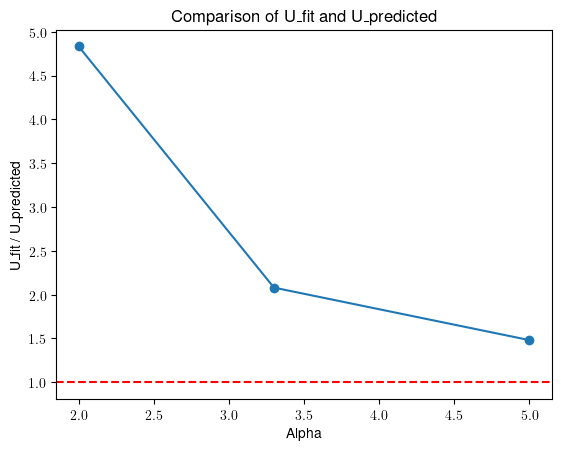

In [9]:
def excluded_volume_rod(alpha):
    second_coeff_A_complete = -5 /32 *np.pi *  (8*alpha / np.pi +2/alpha)
    # second_coeff_A_complete = 16 * alpha / (3*np.pi) 
    second_coeff_B_complete = 5/4
    second_coeff_C_complete = 0.385*8/np.pi

    return (second_coeff_A_complete +second_coeff_B_complete + second_coeff_C_complete)

def correction_density(phi):
    return phi*(1-3/4*phi) / (1-phi)**2

U_predicted = np.zeros(len(alphas))  # Initialize U_predicted for each alpha
for i, alpha in enumerate(alphas):
    volume_fraction = density[i]  
    U_predicted[i] = - excluded_volume_rod(alpha) * correction_density(volume_fraction)
    print(f"Predicted U for alpha {alpha}: {U_predicted[i]:.4f}")
    print(f"Fitted U for alpha {alpha}: {Us[i]:.4f}")

plt.plot(alphas, Us/U_predicted, 'o-', label='U_fit / U_predicted')
plt.xlabel('Alpha')
plt.ylabel('U_fit / U_predicted')
plt.title('Comparison of U_fit and U_predicted')
plt.axhline(1, color='red', linestyle='--', label='U_fit = U_predicted')

print(f"Ratio of U_fit to U_predicted: {Us / U_predicted}")


In [19]:
import numpy as np
from scipy.integrate import quad

phi = np.linspace(-np.pi/2, np.pi/2, 1000)
# interpolate fvals so that it can be evaluated at any theta
f_vals = fit_equilibrium_ODF(phi, S_given[2], Us[2])

# Define the g(theta_2D) function
def g(theta_2D):
    cos_theta = np.cos(theta_2D)
    abs_cos_theta = np.abs(cos_theta)
    # Integrand
    def integrand(t):
        if cos_theta**2 - t**2 <= 0:
            return 0  # Avoid domain error
        # find closest arccos value in phi
        phi_index = np.argmin(np.abs(phi - np.arccos(t)))

        return t * f_vals[phi_index] / np.sqrt(cos_theta**2 - t**2)

    # Numerical integration from 0 to cos(theta_2D)
    integral, _ = quad(integrand, 0, cos_theta)

    # Compute g
    return (1 / (np.pi * abs_cos_theta)) * integral


In [20]:

g_2d = np.zeros_like(phi)

for i, theta in enumerate(phi):
    g_2d[i] = g(theta)

/tmp/ipykernel_36127/924773783.py:22: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral, _ = quad(integrand, 0, cos_theta)
/tmp/ipykernel_36127/924773783.py:22: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral, _ = quad(integrand, 0, cos_theta)


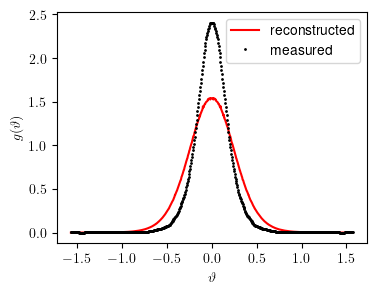

In [21]:
g_2d = g_2d / np.trapezoid(g_2d, phi)  # Normalize the function

plt.figure(figsize=(4,3))
plt.plot(phi, g_2d, 'red', label='reconstructed')

theta_exp = theta_uniform /180 * np.pi
hist_exp = hist_sym / np.trapezoid(hist_sym, theta_exp)  # Normalize the function

plt.plot(theta_exp, hist_exp, 'ko', markersize=1, label='measured')
plt.xlabel('$\\vartheta$')
plt.ylabel('$g(\\vartheta)$')
plt.legend()
plt.savefig('experimental_fit.png', dpi=300, bbox_inches='tight')


